# PlantVillage Pretraining

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Project root

In [2]:
import os

PROJECT_ROOT = "/content/drive/MyDrive/AgriML"

assert os.path.isdir(os.path.join(PROJECT_ROOT, "src", "disease")), (
    f"Couldn't find src/disease under {PROJECT_ROOT}. "
    "Fix PROJECT_ROOT above to point at your project folder."
)
print("Using project root:", PROJECT_ROOT)

Using project root: /content/drive/MyDrive/AgriML


In [3]:
!pip install -q torch torchvision timm albumentations opencv-python pillow numpy matplotlib scikit-learn tqdm flask kaggle

## 4. Kaggle API credentials

In [4]:
from google.colab import files
uploaded = files.upload()

os.makedirs("/root/.kaggle", exist_ok=True)
!cp kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


## 5. PlantVillage dataset from Kaggle

In [5]:
KAGGLE_DL_DIR = "/content/pv_kaggle"
os.makedirs(KAGGLE_DL_DIR, exist_ok=True)

!kaggle datasets download -d mohitsingh1804/plantvillage -p {KAGGLE_DL_DIR} --unzip

train_dir = val_dir = None
for root, dirs, _ in os.walk(KAGGLE_DL_DIR):
    if "train" in dirs and "val" in dirs:
        train_dir = os.path.join(root, "train")
        val_dir = os.path.join(root, "val")
        break

assert train_dir and val_dir, "Could not locate train/ and val/ folders after extraction."
DATA_DIR = os.path.dirname(train_dir)
print("DATA_DIR:", DATA_DIR)
print("Sample train classes:", sorted(os.listdir(train_dir))[:5])
print("Sample val classes:", sorted(os.listdir(val_dir))[:5])

Dataset URL: https://www.kaggle.com/datasets/mohitsingh1804/plantvillage
License(s): GPL-2.0
100% 818M/818M [00:05<00:00, 149MB/s]

DATA_DIR: /content/pv_kaggle/PlantVillage
Sample train classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']
Sample val classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


## 6. Imports

In [6]:
import sys
import time
import json
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.disease.class_mapping import NUM_PV_CLASSES, PV_CLASS_TO_IDX, PV_IDX_TO_CLASS
from src.disease.dataset import create_plantvillage_datasets
from src.disease.model import build_model, get_num_params

## 7. Config

In [7]:
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "weights")
os.makedirs(OUTPUT_DIR, exist_ok=True)

BACKBONE = "mobilenet_v3_large"
BATCH_SIZE = 32
EPOCHS = 15
LR = 1e-3
IMG_SIZE = 224
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [8]:
train_dataset, val_dataset = create_plantvillage_datasets(DATA_DIR, img_size=IMG_SIZE)
print(f"Train samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

/usr/local/lib/python3.13/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Train samples: 43444, Validation samples: 10861


In [9]:
model = build_model(num_classes=NUM_PV_CLASSES, backbone=BACKBONE, pretrained_imagenet=True)
model = model.to(DEVICE)
total_p, train_p = get_num_params(model)
print(f"Total params: {total_p:,}, Trainable: {train_p:,}")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 85.0MB/s]


Total params: 4,250,710, Trainable: 4,250,710


## 8. Training

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

best_val_acc = 0.0
history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, targets in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [Train]"):
        images, targets = images.to(DEVICE), targets.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == targets).sum().item()
        total += targets.size(0)

    train_loss = running_loss / total
    train_acc = (correct / total) * 100.0

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, targets in tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [Val]"):
            images, targets = images.to(DEVICE), targets.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, targets)
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    val_loss = val_loss / val_total
    val_acc = (val_correct / val_total) * 100.0
    scheduler.step()

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc
    })

    print(f"Epoch {epoch:2d}/{EPOCHS:2d} | Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        save_path = os.path.join(OUTPUT_DIR, "plantvillage_pretrained.pth")
        torch.save({
            "epoch": epoch,
            "val_acc": val_acc,
            "num_classes": NUM_PV_CLASSES,
            "backbone": BACKBONE,
            "model_state_dict": model.state_dict(),
            "class_to_idx": PV_CLASS_TO_IDX
        }, save_path)
        print(f"Saved best model checkpoint -> {save_path}")

Epoch 1/15 [Train]:   0%|          | 0/1358 [00:00<?, ?it/s]

Epoch 1/15 [Val]:   0%|          | 0/340 [00:00<?, ?it/s]

Epoch  1/15 | Train Loss: 0.3046 Acc: 90.81% | Val Loss: 0.1674 Acc: 94.60%
Saved best model checkpoint -> /content/drive/MyDrive/AgriML/weights/plantvillage_pretrained.pth


Epoch 2/15 [Train]:   0%|          | 0/1358 [00:00<?, ?it/s]

Epoch 2/15 [Val]:   0%|          | 0/340 [00:00<?, ?it/s]

...

Epoch 14/15 [Val]:   0%|          | 0/340 [00:00<?, ?it/s]

Epoch 14/15 | Train Loss: 0.0058 Acc: 99.82% | Val Loss: 0.0080 Acc: 99.80%
Saved best model checkpoint -> /content/drive/MyDrive/AgriML/weights/plantvillage_pretrained.pth


Epoch 15/15 [Train]:   0%|          | 0/1358 [00:00<?, ?it/s]

Epoch 15/15 [Val]:   0%|          | 0/340 [00:00<?, ?it/s]

Epoch 15/15 | Train Loss: 0.0036 Acc: 99.87% | Val Loss: 0.0082 Acc: 99.77%


## 9. Training curves

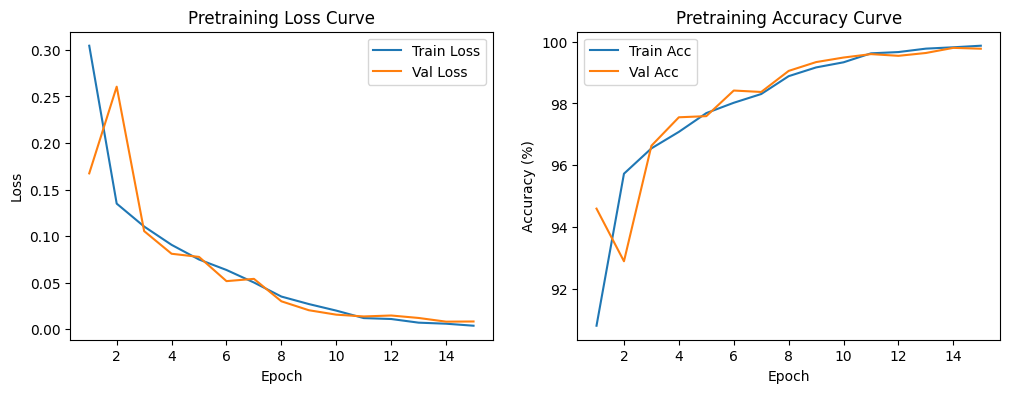

In [12]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot([h['epoch'] for h in history], [h['train_loss'] for h in history], label='Train Loss')
plt.plot([h['epoch'] for h in history], [h['val_loss'] for h in history], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Pretraining Loss Curve')

plt.subplot(1, 2, 2)
plt.plot([h['epoch'] for h in history], [h['train_acc'] for h in history], label='Train Acc')
plt.plot([h['epoch'] for h in history], [h['val_acc'] for h in history], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Pretraining Accuracy Curve')
plt.show()